In [1]:
import os
import pandas as pd

DATASET_PATH = "/kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K/UrbanSound8K"
CSV_PATH     = "/kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K.csv"
AUDIO_BASE   = "/kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K/UrbanSound8K/audio"

metadata_df = pd.read_csv(CSV_PATH)
print("Metadata loaded. First 5 rows:")
display(metadata_df.head())

audio_files = []
for _, row in metadata_df.iterrows():
    file_path = os.path.join(AUDIO_BASE, f"fold{row['fold']}", row['slice_file_name'])
    audio_files.append(file_path)

y_labels = metadata_df['class'].values

print(f"\nTotal audio files : {len(audio_files)}")
print(f"First file exists : {os.path.exists(audio_files[0])}")
print(f"\nFirst 3 paths:")
for p in audio_files[:3]:
    print(f"  {p}")
print(f"\nFirst 5 labels: {y_labels[:5]}")

Metadata loaded. First 5 rows:


,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing



Total audio files : 8732
First file exists : True

First 3 paths:
  /kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K/UrbanSound8K/audio/fold5/100032-3-0-0.wav
  /kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K/UrbanSound8K/audio/fold5/100263-2-0-117.wav
  /kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K/UrbanSound8K/audio/fold5/100263-2-0-121.wav

First 5 labels: <ArrowStringArray>
[        'dog_bark', 'children_playing', 'children_playing',
 'children_playing', 'children_playing']
Length: 5, dtype: str


In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input/datasets/rupakroy/urban-sound-8k"):
    # Print every directory that contains .wav files
    wav_files = [f for f in files if f.endswith(".wav")]
    if wav_files:
        print(f"DIR: {root}")
        print(f"  Sample file: {wav_files[0]}")
        print(f"  Total wavs: {len(wav_files)}")

DIR: /kaggle/input/datasets/rupakroy/urban-sound-8k
  Sample file: sample.wav
  Total wavs: 1


DIR: /kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K/UrbanSound8K/audio/fold7
  Sample file: 164797-2-0-8.wav
  Total wavs: 838


DIR: /kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K/UrbanSound8K/audio/fold1
  Sample file: 78360-4-0-7.wav
  Total wavs: 873


DIR: /kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K/UrbanSound8K/audio/fold3
  Sample file: 165039-7-3-0.wav
  Total wavs: 925


DIR: /kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K/UrbanSound8K/audio/fold5
  Sample file: 162432-6-7-0.wav
  Total wavs: 936


...

DIR: /kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K/UrbanSound8K/audio/fold9
  Sample file: 13579-2-0-48.wav
  Total wavs: 816


DIR: /kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K/UrbanSound8K/audio/fold8
  Sample file: 74677-0-0-116.wav
  Total wavs: 806


DIR: /kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K/UrbanSound8K/audio/fold4
  Sample file: 171305-7-14-0.wav
  Total wavs: 990


DIR: /kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K/UrbanSound8K/audio/fold2
  Sample file: 76086-4-0-58.wav
  Total wavs: 888


DIR: /kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K/UrbanSound8K/audio/fold6
  Sample file: 107842-4-2-4.wav
  Total wavs: 823


In [3]:
!pip install librosa --quiet
import librosa

selected_audio_clips = audio_files[:3]

print("Audio Clip Details:")
for clip_path in selected_audio_clips:
    y, sr = librosa.load(clip_path, sr=None)
    duration = librosa.get_duration(y=y, sr=sr)
    print(f"\nFile: {os.path.basename(clip_path)}")
    print(f"  Sampling Rate: {sr} Hz")
    print(f"  Duration: {duration:.2f} seconds")


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Audio Clip Details:



File: 100032-3-0-0.wav
  Sampling Rate: 44100 Hz
  Duration: 0.32 seconds

File: 100263-2-0-117.wav
  Sampling Rate: 44100 Hz
  Duration: 4.00 seconds

File: 100263-2-0-121.wav
  Sampling Rate: 44100 Hz
  Duration: 4.00 seconds


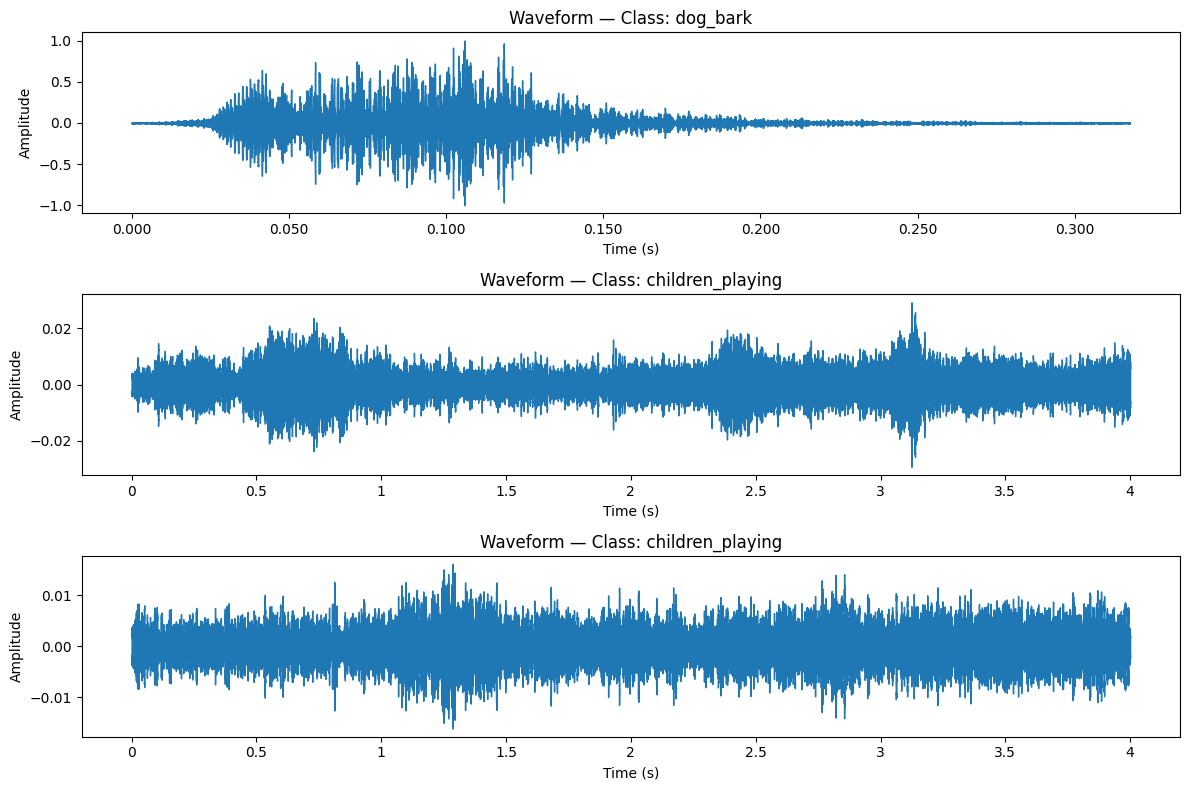

In [4]:
import librosa.display
import matplotlib.pyplot as plt

selected_audio_info = []
for clip_path in selected_audio_clips:
    fname = os.path.basename(clip_path)
    row = metadata_df[metadata_df['slice_file_name'] == fname]
    audio_class = row['class'].values[0] if len(row) > 0 else "unknown"
    selected_audio_info.append({'file_path': clip_path, 'class': audio_class})

plt.figure(figsize=(12, 8))
for i, audio_info in enumerate(selected_audio_info):
    y, sr = librosa.load(audio_info['file_path'], sr=None)
    plt.subplot(len(selected_audio_info), 1, i + 1)
    librosa.display.waveshow(y=y, sr=sr)
    plt.title(f"Waveform — Class: {audio_info['class']}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

In [5]:
import numpy as np

def extract_features(file_path):
    try:
        y, sr = librosa.load(file_path, sr=None)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        zero_crossing_rate = librosa.feature.zero_crossing_rate(y=y)
        chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr)
        return {
            'mfccs_mean': np.mean(mfccs),
            'spectral_centroid_mean': np.mean(spectral_centroid),
            'zero_crossing_rate_mean': np.mean(zero_crossing_rate),
            'chroma_stft_mean': np.mean(chroma_stft)
        }
    except Exception as e:
        print(f"Error: {file_path} — {e}")
        return None

all_features = []
print(f"Extracting features from {len(audio_files)} files...")
for i, file_path in enumerate(audio_files):
    if i % 1000 == 0:
        print(f"  Processing {i}/{len(audio_files)}")
    feat = extract_features(file_path)
    if feat:
        all_features.append(feat)

print(f"\nDone. Extracted features for {len(all_features)} files.")
print("\nFirst 3 feature sets:")
for j, fs in enumerate(all_features[:3]):
    print(f"  Set {j+1}: {fs}")

Extracting features from 8732 files...
  Processing 0/8732


/usr/local/lib/python3.12/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


  Processing 1000/8732


  Processing 2000/8732


/usr/local/lib/python3.12/site-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


...

  Processing 5000/8732


  Processing 6000/8732


  Processing 7000/8732


  Processing 8000/8732



Done. Extracted features for 8732 files.

First 3 feature sets:
  Set 1: {'mfccs_mean': np.float32(-28.461056), 'spectral_centroid_mean': np.float64(2501.385833578897), 'zero_crossing_rate_mean': np.float64(0.06630161830357142), 'chroma_stft_mean': np.float32(0.35578415)}
  Set 2: {'mfccs_mean': np.float32(-22.995636), 'spectral_centroid_mean': np.float64(2232.577799235229), 'zero_crossing_rate_mean': np.float64(0.07166694972826088), 'chroma_stft_mean': np.float32(0.50677365)}
  Set 3: {'mfccs_mean': np.float32(-24.061419), 'spectral_centroid_mean': np.float64(1956.5270037870075), 'zero_crossing_rate_mean': np.float64(0.05259001358695652), 'chroma_stft_mean': np.float32(0.5658122)}


Generating Spectrograms:


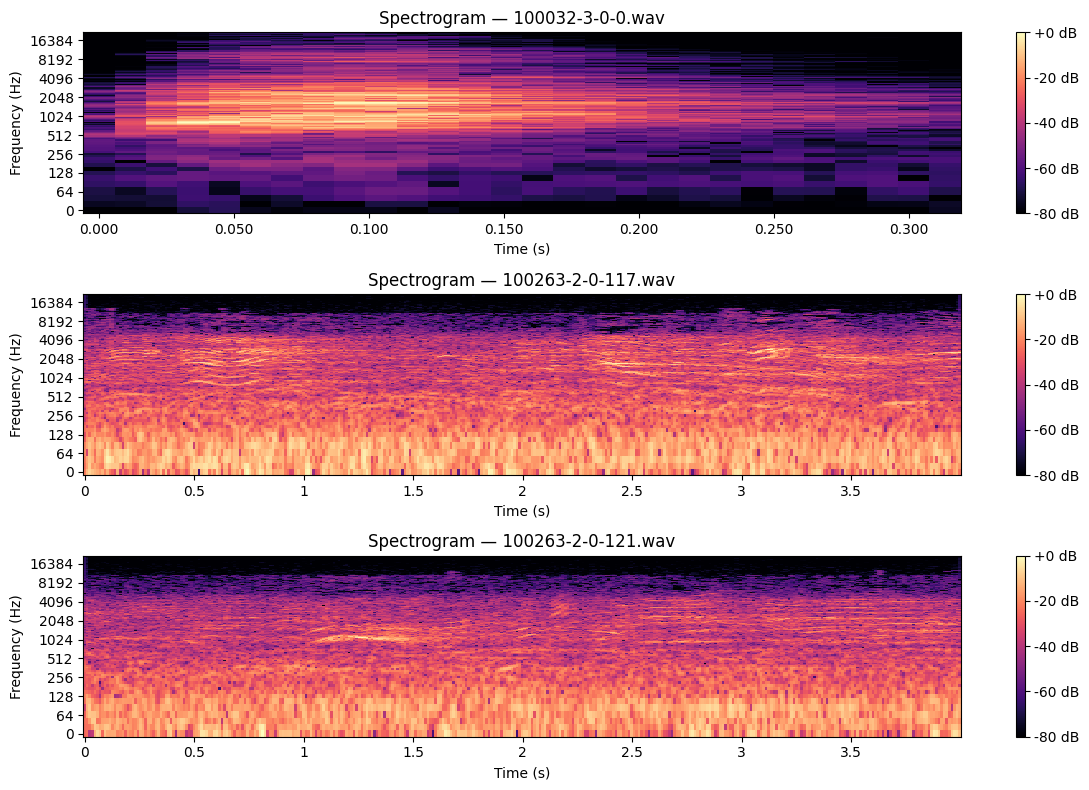

In [6]:
plt.figure(figsize=(12, 8))
print("Generating Spectrograms:")
for i, clip_path in enumerate(selected_audio_clips):
    y, sr = librosa.load(clip_path, sr=None)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    plt.subplot(len(selected_audio_clips), 1, i + 1)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Spectrogram — {os.path.basename(clip_path)}")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
plt.tight_layout()
plt.show()

Generating MFCC Heatmaps:


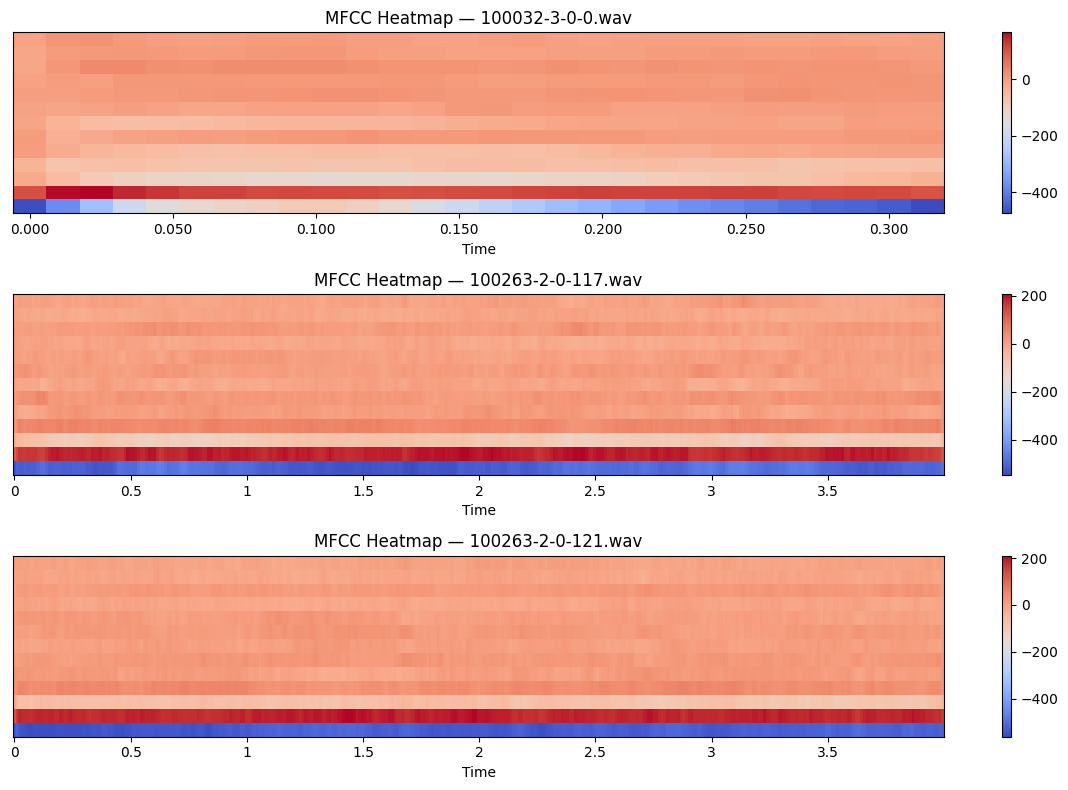

In [7]:
plt.figure(figsize=(12, 8))
print("Generating MFCC Heatmaps:")
for i, clip_path in enumerate(selected_audio_clips):
    y, sr = librosa.load(clip_path, sr=None)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    plt.subplot(len(selected_audio_clips), 1, i + 1)
    librosa.display.specshow(mfccs, sr=sr, x_axis='time')
    plt.colorbar()
    plt.title(f"MFCC Heatmap — {os.path.basename(clip_path)}")
plt.tight_layout()
plt.show()

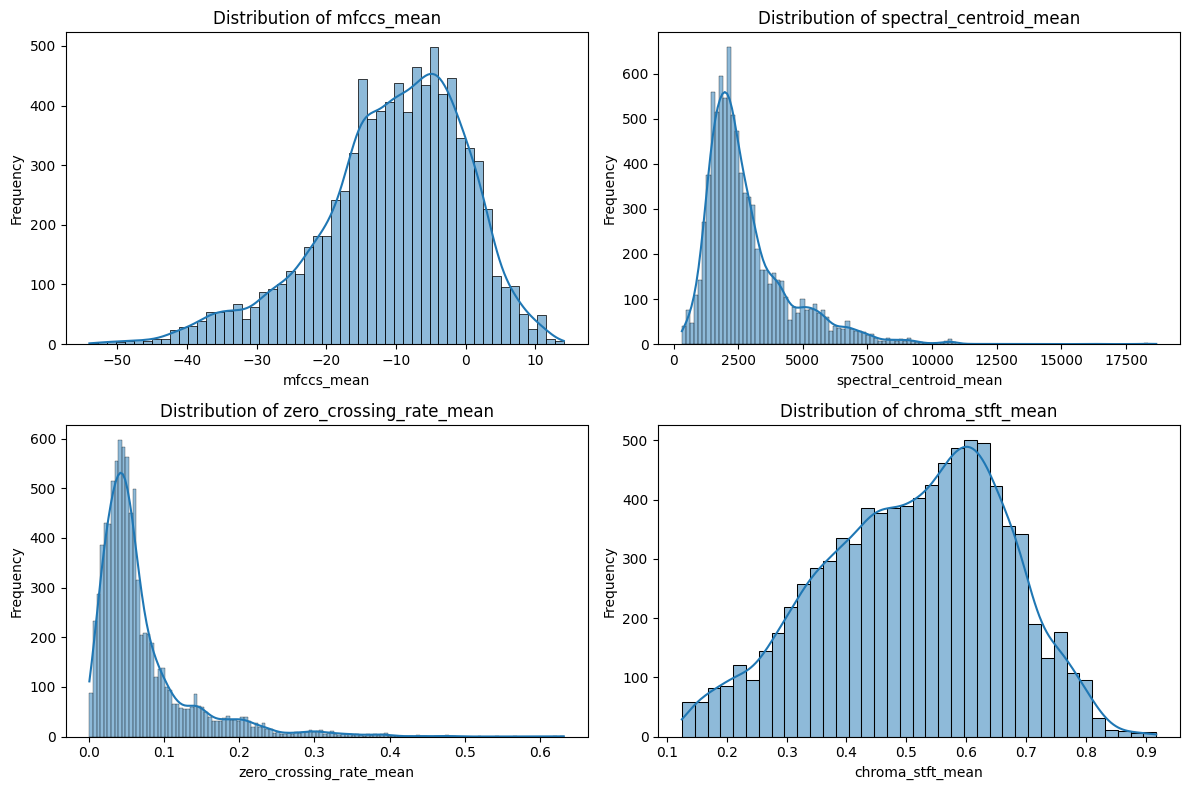

In [8]:
import seaborn as sns
import pandas as pd

features_df = pd.DataFrame(all_features)

plt.figure(figsize=(12, 8))
for i, col in enumerate(features_df.columns):
    plt.subplot(2, 2, i + 1)
    sns.histplot(features_df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("First 5 feature vectors:")
display(features_df.head())

scaler = StandardScaler()
X = features_df.values
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features_df.columns)

print("\nFirst 5 scaled rows:")
display(X_scaled_df.head())

# Fix: convert y_labels to plain numpy array
y_labels_np = metadata_df['class'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_labels_np, test_size=0.2, random_state=42
)

print(f"\nX_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

First 5 feature vectors:


,mfccs_mean,spectral_centroid_mean,zero_crossing_rate_mean,chroma_stft_mean
0,-28.461056,2501.385834,0.066302,0.355784
1,-22.995636,2232.577799,0.071667,0.506774
2,-24.061419,1956.527004,0.052590,0.565812
3,-21.945129,2652.462734,0.072764,0.479502
4,-23.601200,2095.392609,0.060884,0.555145



First 5 scaled rows:


,mfccs_mean,spectral_centroid_mean,zero_crossing_rate_mean,chroma_stft_mean
0,-1.697713,-0.202860,-0.062906,-1.023887
1,-1.181577,-0.363904,0.019251,-0.029991
2,-1.282226,-0.529288,-0.272866,0.358634
3,-1.082371,-0.112349,0.036047,-0.209506
4,-1.238764,-0.446093,-0.145868,0.288418



X_train: (6985, 4), X_test: (1747, 4)
y_train: (6985,), y_test: (1747,)


In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

classifiers = {
    'KNeighborsClassifier': KNeighborsClassifier(),
    'DecisionTreeClassifier': DecisionTreeClassifier(random_state=42),
    'RandomForestClassifier': RandomForestClassifier(random_state=42),
    'GaussianNB': GaussianNB(),
    'SVC': SVC(random_state=42)
}

model_predictions = {}
for name, clf in classifiers.items():
    print(f"Training {name}...")
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    model_predictions[name] = preds
    print(f"  First 5 predictions: {preds[:5]}")

print("\nAll classifiers trained.")

Training KNeighborsClassifier...
  First 5 predictions: ['jackhammer' 'street_music' 'drilling' 'siren' 'gun_shot']
Training DecisionTreeClassifier...
  First 5 predictions: ['gun_shot' 'siren' 'drilling' 'siren' 'gun_shot']
Training RandomForestClassifier...


  First 5 predictions: ['jackhammer' 'street_music' 'drilling' 'siren' 'gun_shot']
Training GaussianNB...
  First 5 predictions: ['engine_idling' 'siren' 'drilling' 'siren' 'engine_idling']
Training SVC...


  First 5 predictions: ['jackhammer' 'street_music' 'drilling' 'siren' 'engine_idling']

All classifiers trained.



KNeighborsClassifier:
  Accuracy=0.6697, Precision=0.6733, Recall=0.6697, F1=0.6665

DecisionTreeClassifier:
  Accuracy=0.5953, Precision=0.5917, Recall=0.5953, F1=0.5927



RandomForestClassifier:
  Accuracy=0.6989, Precision=0.6987, Recall=0.6989, F1=0.6967



GaussianNB:
  Accuracy=0.3412, Precision=0.3802, Recall=0.3412, F1=0.3198



SVC:
  Accuracy=0.4780, Precision=0.4926, Recall=0.4780, F1=0.4690


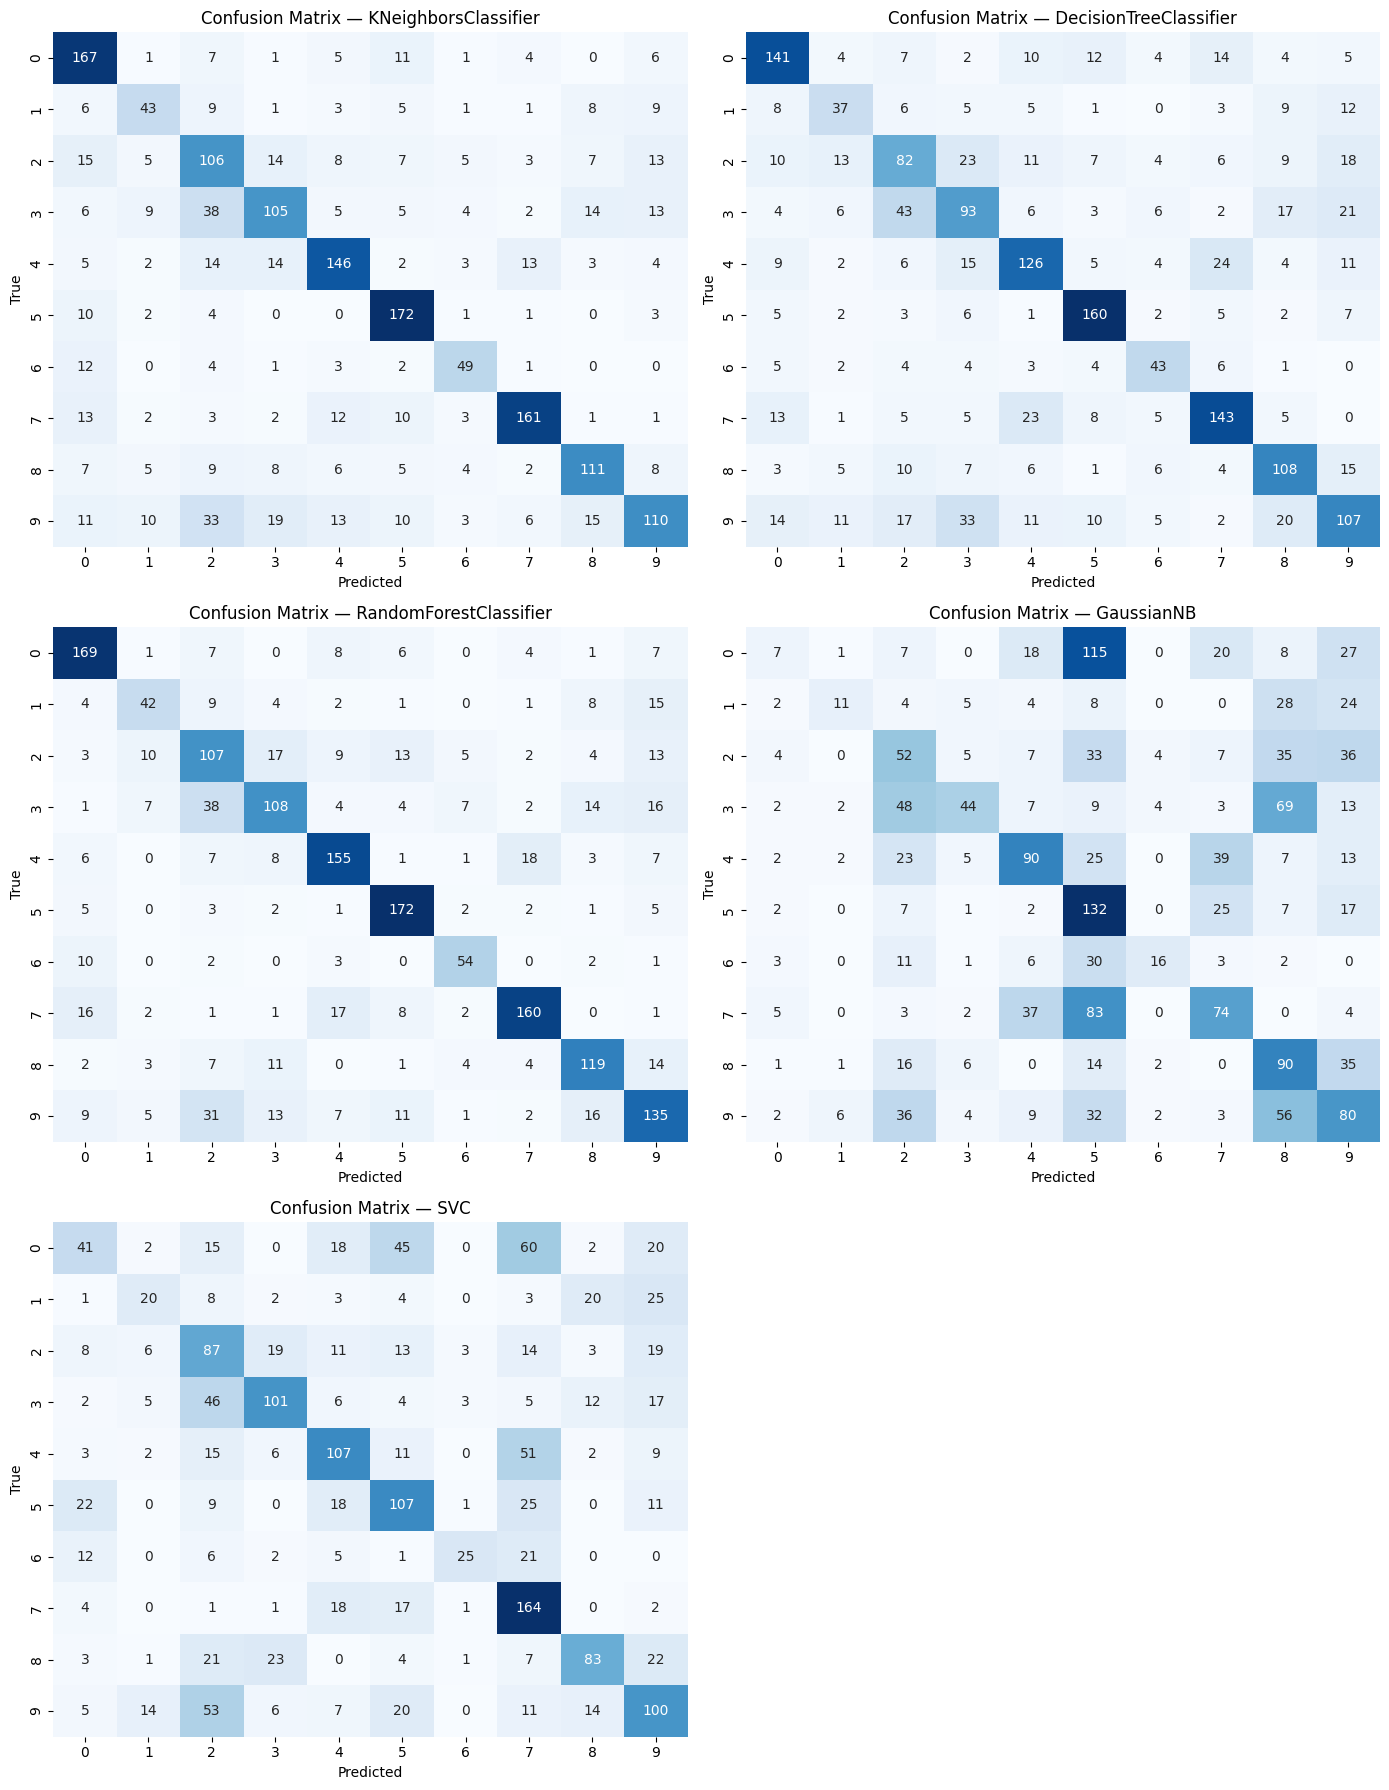


Combined Features Performance Summary:


,accuracy_combined,precision_combined,recall_combined,f1_score_combined
KNeighborsClassifier,0.669720,0.673310,0.669720,0.666491
DecisionTreeClassifier,0.595306,0.591684,0.595306,0.592674
RandomForestClassifier,0.698912,0.698669,0.698912,0.696703
GaussianNB,0.341156,0.380225,0.341156,0.319759
SVC,0.477962,0.492631,0.477962,0.468950


In [11]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

results = {}
rows = (len(model_predictions) + 1) // 2

plt.figure(figsize=(14, 6 * rows))
for i, (name, preds) in enumerate(model_predictions.items()):
    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted', zero_division=0)
    rec  = recall_score(y_test, preds, average='weighted', zero_division=0)
    f1   = f1_score(y_test, preds, average='weighted', zero_division=0)
    results[name] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1_score': f1}

    print(f"\n{name}:")
    print(f"  Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")

    cm = confusion_matrix(y_test, preds)
    plt.subplot(rows, 2, i + 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")

plt.tight_layout()
plt.show()

combined_features_results_df = pd.DataFrame(results).T
combined_features_results_df.rename(columns=lambda x: x + '_combined', inplace=True)
print("\nCombined Features Performance Summary:")
display(combined_features_results_df)

In [12]:
def add_noise(audio, noise_type='white', snr_db=10):
    signal_power = np.mean(audio**2)
    if noise_type == 'white':
        noise = np.random.randn(len(audio))
    elif noise_type == 'pink':
        noise = np.convolve(np.random.randn(len(audio)), [1, 0.5, 0.25, 0.125], mode='same')
    elif noise_type == 'brown':
        noise = np.cumsum(np.random.randn(len(audio)))
        noise -= np.mean(noise)
    noise_power = np.mean(noise**2)
    noise_scaled = noise * np.sqrt((signal_power / (10**(snr_db/10))) / noise_power)
    return audio + noise_scaled

def extract_features_noisy(file_path, snr_db=10):
    try:
        y, sr = librosa.load(file_path, sr=None)
        y_noisy = add_noise(y, snr_db=snr_db)
        return {
            'mfccs_mean': np.mean(librosa.feature.mfcc(y=y_noisy, sr=sr, n_mfcc=13)),
            'spectral_centroid_mean': np.mean(librosa.feature.spectral_centroid(y=y_noisy, sr=sr)),
            'zero_crossing_rate_mean': np.mean(librosa.feature.zero_crossing_rate(y=y_noisy)),
            'chroma_stft_mean': np.mean(librosa.feature.chroma_stft(y=y_noisy, sr=sr))
        }
    except Exception as e:
        print(f"Error: {file_path} — {e}")
        return None

snr_level_db = 10
all_features_noisy = []
print(f"Extracting noisy features (SNR={snr_level_db} dB)...")
for i, file_path in enumerate(audio_files):
    if i % 1000 == 0:
        print(f"  {i}/{len(audio_files)}")
    feat = extract_features_noisy(file_path, snr_db=snr_level_db)
    if feat:
        all_features_noisy.append(feat)

print(f"\nDone. {len(all_features_noisy)} noisy feature sets extracted.")
print(f"\nFirst 3 noisy feature sets (SNR={snr_level_db} dB):")
for j, fs in enumerate(all_features_noisy[:3]):
    print(f"  Set {j+1}: {fs}")

Extracting noisy features (SNR=10 dB)...
  0/8732


/usr/local/lib/python3.12/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


  1000/8732


  2000/8732


/usr/local/lib/python3.12/site-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


...

  5000/8732


  6000/8732


  7000/8732


  8000/8732



Done. 8732 noisy feature sets extracted.

First 3 noisy feature sets (SNR=10 dB):
  Set 1: {'mfccs_mean': np.float64(-7.853916961831912), 'spectral_centroid_mean': np.float64(8667.906544130952), 'zero_crossing_rate_mean': np.float64(0.2940673828125), 'chroma_stft_mean': np.float64(0.5434913639755566)}
  Set 2: {'mfccs_mean': np.float64(-20.52908084843704), 'spectral_centroid_mean': np.float64(6999.001268428359), 'zero_crossing_rate_mean': np.float64(0.16391247735507247), 'chroma_stft_mean': np.float64(0.5212810238326044)}
  Set 3: {'mfccs_mean': np.float64(-21.6341455479919), 'spectral_centroid_mean': np.float64(6987.046614529992), 'zero_crossing_rate_mean': np.float64(0.1492753623188406), 'chroma_stft_mean': np.float64(0.5766282131529593)}


X_noisy_train: (6985, 4), X_noisy_test: (1747, 4)
Training KNeighborsClassifier (noisy)...
Training DecisionTreeClassifier (noisy)...
Training RandomForestClassifier (noisy)...


Training GaussianNB (noisy)...
Training SVC (noisy)...


KNeighborsClassifier: Acc=0.6600, Prec=0.6585, Rec=0.6600, F1=0.6545
DecisionTreeClassifier: Acc=0.5747, Prec=0.5750, Rec=0.5747, F1=0.5736


RandomForestClassifier: Acc=0.7018, Prec=0.6988, Rec=0.7018, F1=0.6978
GaussianNB: Acc=0.3314, Prec=0.3576, Rec=0.3314, F1=0.3148


SVC: Acc=0.5146, Prec=0.5312, Rec=0.5146, F1=0.5122


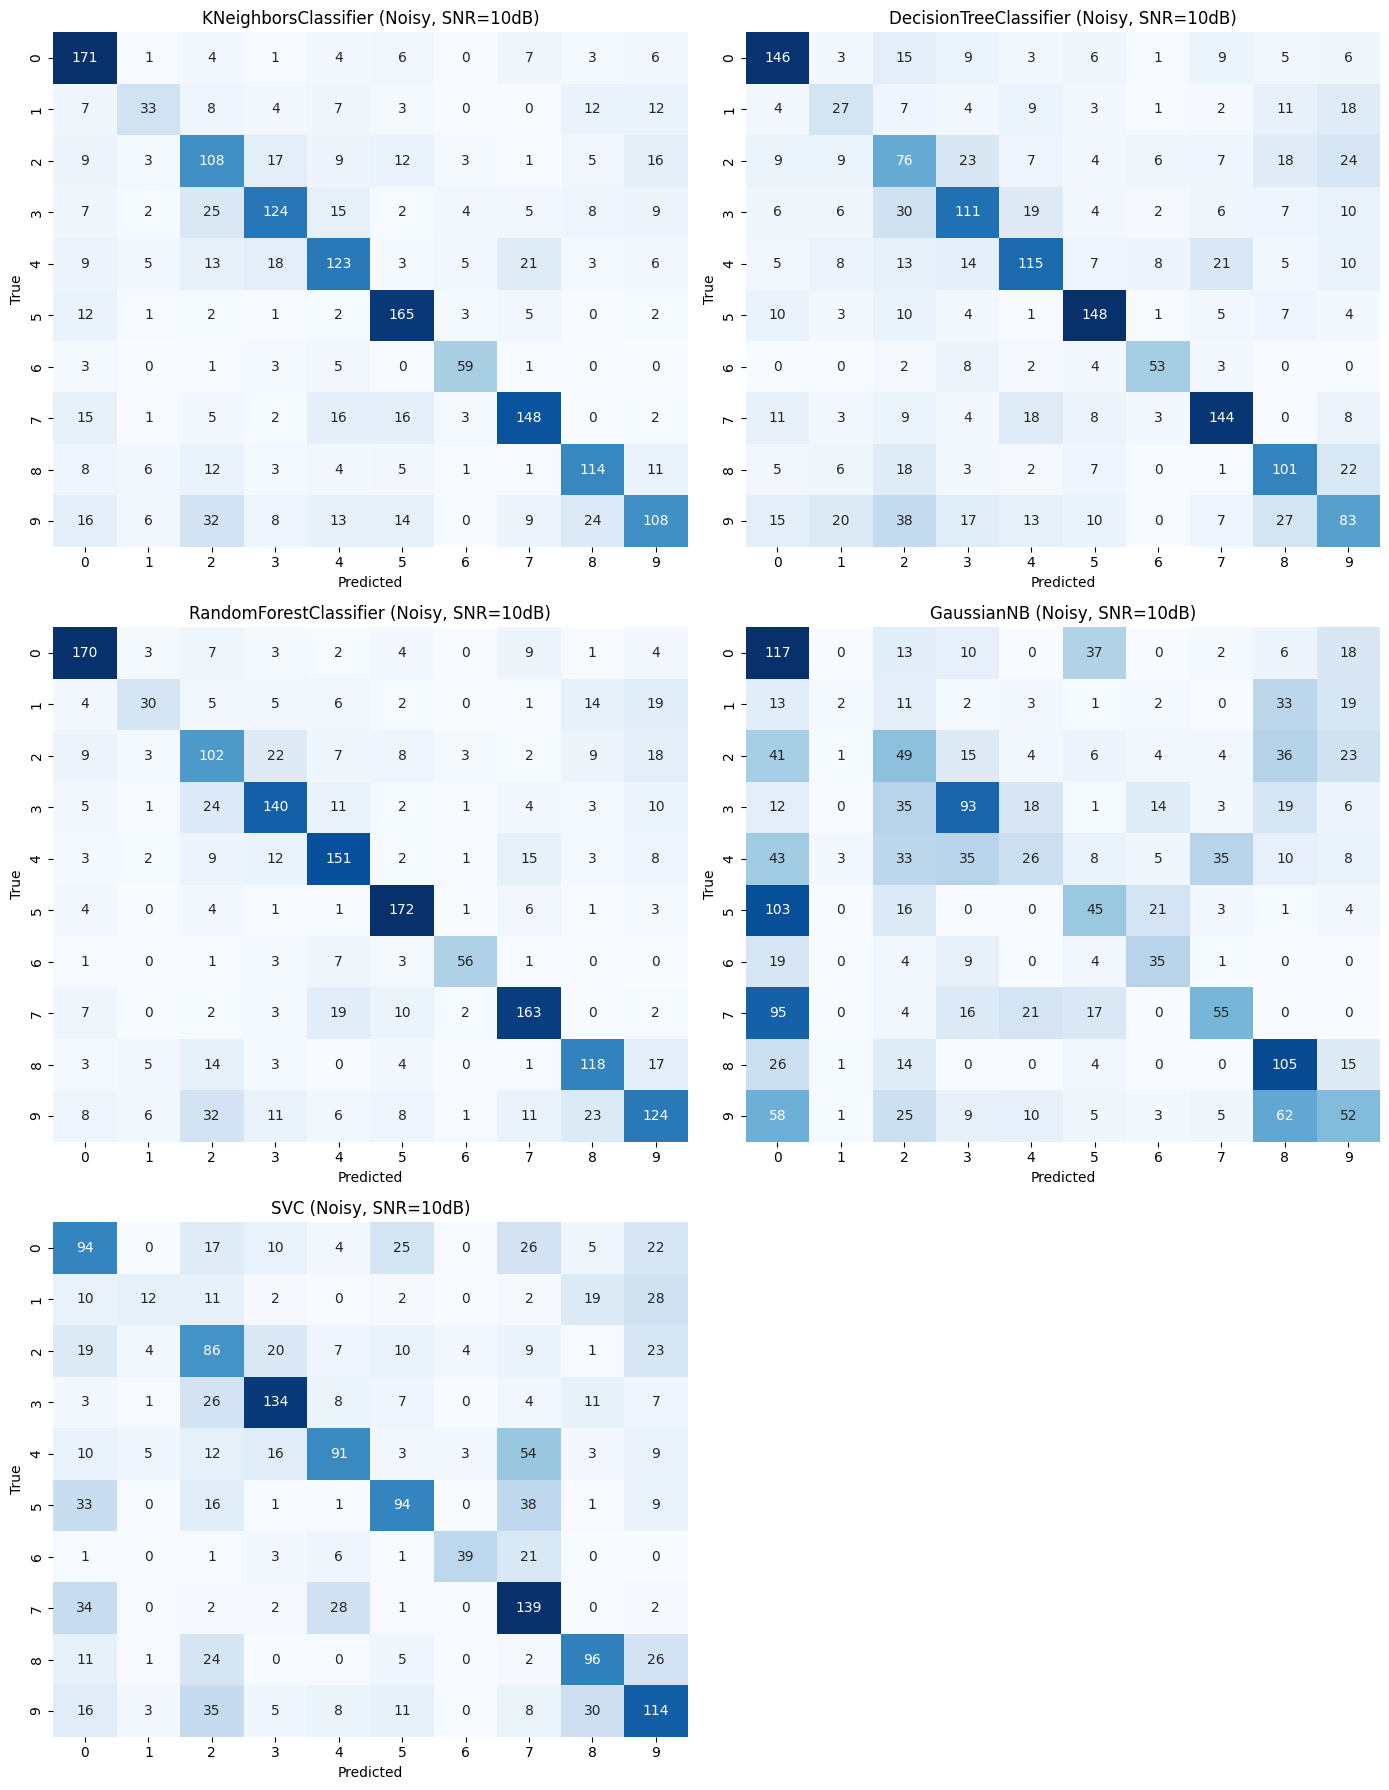


Noise Robustness Summary (SNR=10 dB):


,accuracy,precision,recall,f1_score
KNeighborsClassifier,0.659989,0.658472,0.659989,0.654469
DecisionTreeClassifier,0.574699,0.575006,0.574699,0.573587
RandomForestClassifier,0.701774,0.698832,0.701774,0.697831
GaussianNB,0.331425,0.357585,0.331425,0.314843
SVC,0.514596,0.531217,0.514596,0.512220


In [13]:
noisy_features_df = pd.DataFrame(all_features_noisy)

scaler_noisy = StandardScaler()
X_noisy_scaled = scaler_noisy.fit_transform(noisy_features_df.values)

y_labels_np = metadata_df['class'].to_numpy()  # Fix

X_noisy_train, X_noisy_test, y_noisy_train, y_noisy_test = train_test_split(
    X_noisy_scaled, y_labels_np, test_size=0.2, random_state=42
)

print(f"X_noisy_train: {X_noisy_train.shape}, X_noisy_test: {X_noisy_test.shape}")

classifiers_noisy = {
    'KNeighborsClassifier': KNeighborsClassifier(),
    'DecisionTreeClassifier': DecisionTreeClassifier(random_state=42),
    'RandomForestClassifier': RandomForestClassifier(random_state=42),
    'GaussianNB': GaussianNB(),
    'SVC': SVC(random_state=42)
}

noise_model_predictions = {}
for name, clf in classifiers_noisy.items():
    print(f"Training {name} (noisy)...")
    clf.fit(X_noisy_train, y_noisy_train)
    noise_model_predictions[name] = clf.predict(X_noisy_test)

noise_results = {}
rows = (len(noise_model_predictions) + 1) // 2
plt.figure(figsize=(14, 6 * rows))

for i, (name, preds) in enumerate(noise_model_predictions.items()):
    acc  = accuracy_score(y_noisy_test, preds)
    prec = precision_score(y_noisy_test, preds, average='weighted', zero_division=0)
    rec  = recall_score(y_noisy_test, preds, average='weighted', zero_division=0)
    f1   = f1_score(y_noisy_test, preds, average='weighted', zero_division=0)
    noise_results[name] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1_score': f1}
    print(f"{name}: Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}")

    cm = confusion_matrix(y_noisy_test, preds)
    plt.subplot(rows, 2, i + 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"{name} (Noisy, SNR={snr_level_db}dB)")
    plt.xlabel("Predicted")
    plt.ylabel("True")

plt.tight_layout()
plt.show()

noise_results_df = pd.DataFrame(noise_results).T
print(f"\nNoise Robustness Summary (SNR={snr_level_db} dB):")
display(noise_results_df)

In [14]:
def extract_mfcc_features(file_path):
    try:
        y, sr = librosa.load(file_path, sr=None)
        return np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13), axis=1)
    except Exception as e:
        print(f"Error: {file_path} — {e}")
        return None

all_mfcc_features = []
print(f"Extracting MFCC-only features from {len(audio_files)} files...")
for i, file_path in enumerate(audio_files):
    if i % 1000 == 0:
        print(f"  {i}/{len(audio_files)}")
    vec = extract_mfcc_features(file_path)
    if vec is not None:
        all_mfcc_features.append(vec)

mfcc_features_df = pd.DataFrame(all_mfcc_features,
                                 columns=[f'mfcc_{i}' for i in range(13)])
print(f"\nMFCC DataFrame shape: {mfcc_features_df.shape}")
display(mfcc_features_df.head())

Extracting MFCC-only features from 8732 files...
  0/8732


  1000/8732


  2000/8732


/usr/local/lib/python3.12/site-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


  3000/8732


...

  6000/8732


  7000/8732


  8000/8732



MFCC DataFrame shape: (8732, 13)


,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12
0,-275.918427,119.492790,-98.211777,-66.515137,-42.606045,0.505065,-28.330936,-5.746867,9.992787,4.795412,15.461892,-0.069880,-2.842673
1,-500.908386,185.106415,-86.532822,49.858849,9.230822,22.548956,-3.567175,12.220052,7.720082,-6.460392,16.995657,-6.625117,1.469779
2,-531.195312,186.939941,-70.349159,40.429245,9.121048,18.398588,6.283282,15.504061,9.613500,-7.113611,16.179823,-5.710522,-0.899251
3,-476.784424,160.333282,-62.952843,50.751171,-0.174330,32.791603,-17.469801,24.755478,-3.847783,-1.761176,14.020372,-11.238716,6.290466
4,-521.244690,185.392639,-81.950470,46.473549,11.872088,23.491444,4.261836,13.637699,6.093238,-2.813453,18.077290,-7.257346,-2.849374


Training KNeighborsClassifier (MFCC-only)...
Training DecisionTreeClassifier (MFCC-only)...


Training RandomForestClassifier (MFCC-only)...


Training GaussianNB (MFCC-only)...
Training SVC (MFCC-only)...


KNeighborsClassifier: Acc=0.8867, Prec=0.8888, Rec=0.8867, F1=0.8853
DecisionTreeClassifier: Acc=0.7310, Prec=0.7316, Rec=0.7310, F1=0.7306
RandomForestClassifier: Acc=0.8987, Prec=0.9020, Rec=0.8987, F1=0.8980


GaussianNB: Acc=0.4740, Prec=0.4798, Rec=0.4740, F1=0.4697


SVC: Acc=0.8180, Prec=0.8213, Rec=0.8180, F1=0.8178


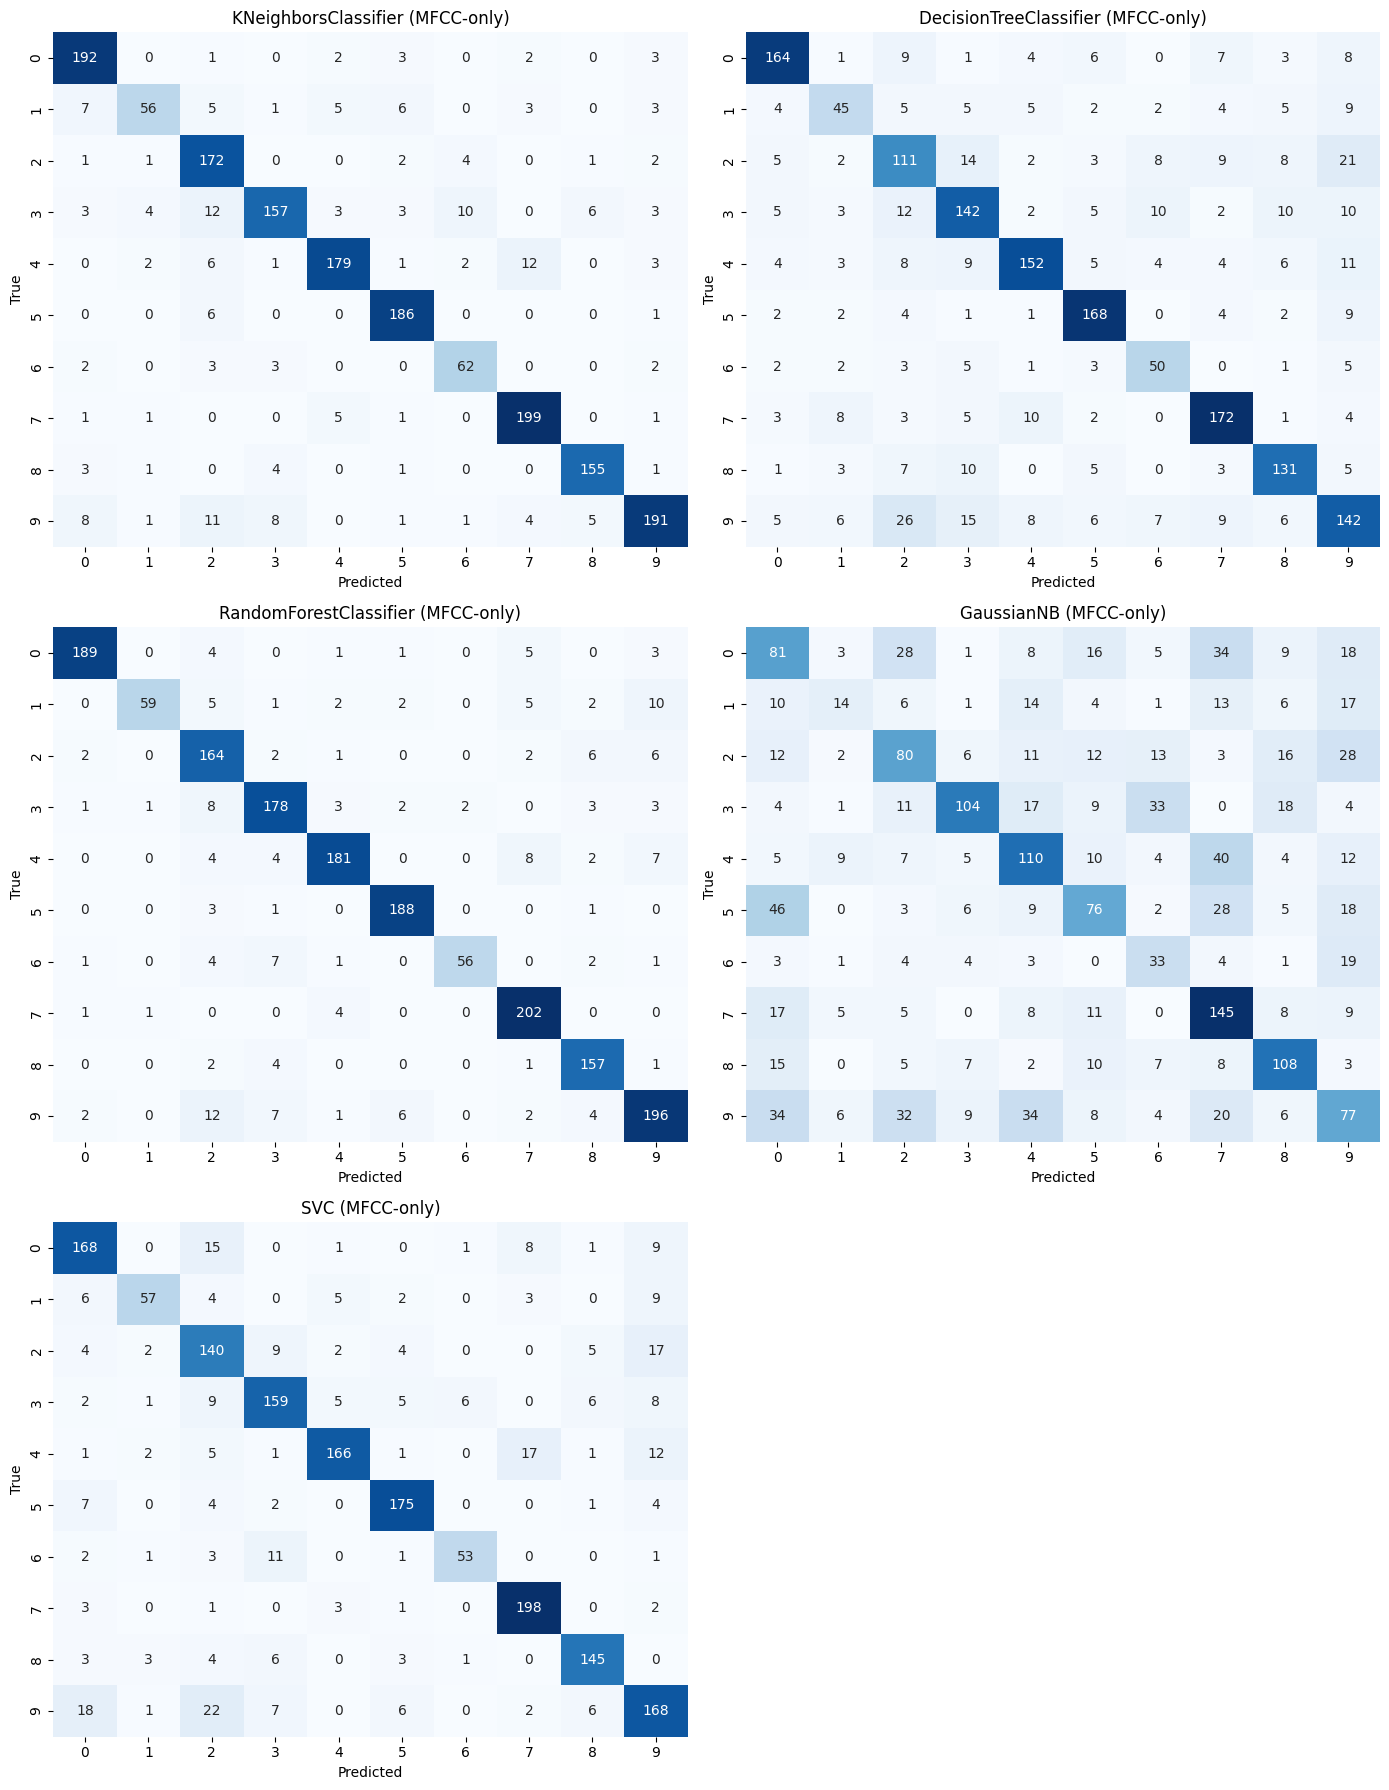


MFCC-only Performance Summary:


,accuracy,precision,recall,f1_score
KNeighborsClassifier,0.886663,0.888778,0.886663,0.885265
DecisionTreeClassifier,0.730967,0.731567,0.730967,0.730552
RandomForestClassifier,0.898683,0.901964,0.898683,0.897977
GaussianNB,0.473955,0.479780,0.473955,0.469678
SVC,0.817974,0.821322,0.817974,0.817843


In [15]:
y_labels_np = metadata_df['class'].to_numpy()  # Fix

scaler_mfcc = StandardScaler()
X_mfcc_scaled = scaler_mfcc.fit_transform(mfcc_features_df.values)

X_mfcc_train, X_mfcc_test, y_mfcc_train, y_mfcc_test = train_test_split(
    X_mfcc_scaled, y_labels_np, test_size=0.2, random_state=42
)

classifiers_mfcc = {
    'KNeighborsClassifier': KNeighborsClassifier(),
    'DecisionTreeClassifier': DecisionTreeClassifier(random_state=42),
    'RandomForestClassifier': RandomForestClassifier(random_state=42),
    'GaussianNB': GaussianNB(),
    'SVC': SVC(random_state=42)
}

mfcc_model_predictions = {}
for name, clf in classifiers_mfcc.items():
    print(f"Training {name} (MFCC-only)...")
    clf.fit(X_mfcc_train, y_mfcc_train)
    mfcc_model_predictions[name] = clf.predict(X_mfcc_test)

mfcc_results = {}
rows = (len(mfcc_model_predictions) + 1) // 2
plt.figure(figsize=(14, 6 * rows))

for i, (name, preds) in enumerate(mfcc_model_predictions.items()):
    acc  = accuracy_score(y_mfcc_test, preds)
    prec = precision_score(y_mfcc_test, preds, average='weighted', zero_division=0)
    rec  = recall_score(y_mfcc_test, preds, average='weighted', zero_division=0)
    f1   = f1_score(y_mfcc_test, preds, average='weighted', zero_division=0)
    mfcc_results[name] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1_score': f1}
    print(f"{name}: Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}")

    cm = confusion_matrix(y_mfcc_test, preds)
    plt.subplot(rows, 2, i + 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"{name} (MFCC-only)")
    plt.xlabel("Predicted")
    plt.ylabel("True")

plt.tight_layout()
plt.show()

mfcc_results_df = pd.DataFrame(mfcc_results).T
print("\nMFCC-only Performance Summary:")
display(mfcc_results_df)

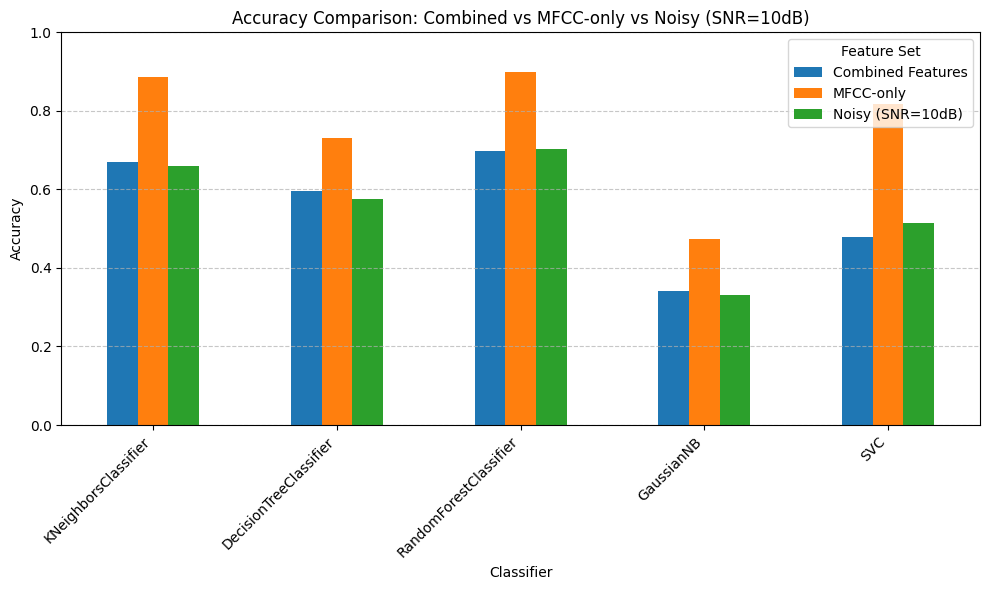


Full Comparison Table:


,accuracy_combined,precision_combined,recall_combined,f1_score_combined,accuracy,precision,recall,f1_score
KNeighborsClassifier,0.669720,0.673310,0.669720,0.666491,0.886663,0.888778,0.886663,0.885265
DecisionTreeClassifier,0.595306,0.591684,0.595306,0.592674,0.730967,0.731567,0.730967,0.730552
RandomForestClassifier,0.698912,0.698669,0.698912,0.696703,0.898683,0.901964,0.898683,0.897977
GaussianNB,0.341156,0.380225,0.341156,0.319759,0.473955,0.479780,0.473955,0.469678
SVC,0.477962,0.492631,0.477962,0.468950,0.817974,0.821322,0.817974,0.817843


In [16]:
comparison_df = pd.DataFrame({
    'Combined Features': combined_features_results_df['accuracy_combined'],
    'MFCC-only': mfcc_results_df['accuracy'],
    f'Noisy (SNR={snr_level_db}dB)': noise_results_df['accuracy']
})

comparison_df.plot(kind='bar', figsize=(10, 6))
plt.title(f'Accuracy Comparison: Combined vs MFCC-only vs Noisy (SNR={snr_level_db}dB)')
plt.xlabel('Classifier')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.legend(title='Feature Set')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nFull Comparison Table:")
display(pd.concat([combined_features_results_df, mfcc_results_df], axis=1))